In [ ]:
import pathlib

In [ ]:
import marimo as mo
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
from conduitpylib.wrangle import (
    find_treat_idx_mapped_col,
    retrieve_and_prepare_delta_dataframes,
)

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-22T01:48:08.354018+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

scipy     : 1.14.1
pandas    : 2.2.3
seaborn   : 0.13.2
numpy     : 2.1.2
requests  : 2.34.2
marimo    : 0.23.2
teeplot   : 1.4.2
matplotlib: 3.9.2

```

## Prep Data

In [ ]:
for slug in "jgpnv", "ncdfq":
    with open(f"/tmp/{slug}", "wb") as _fp:
        _fp.write(
            requests.get(
                f"https://osf.io/{slug}/download", allow_redirects=True
            ).content,
        )

merge_df, (
    df_finalized_observations,
    df_snapshot_diffs,
) = retrieve_and_prepare_delta_dataframes(
    df_inlet_url="/tmp/jgpnv",
    df_outlet_url="/tmp/ncdfq",
    treatment_column="Allocation",
    return_merge_df=True,
)

allocation_idx_mapped_title = find_treat_idx_mapped_col(df_snapshot_diffs)
allocation_idx_mapped_title

a: df_inlet
digest: 0a67179718d03240e90c2558d41c387ea98478bb3fcd462644ca985a860057e5
num cols: 45
num cols all na: 2
num cols any na: 2
num na: 133120
num rows: 66560
num rows all na: 0
num rows any na: 66560
size: 62M

a: df_outlet
digest: 98595207b6985f49ec331d78584c44aa98ef333032fa410f79c3b8306cbcfcb6
num cols: 71
num cols all na: 6
num cols any na: 6
num na: 399360
num rows: 66560
num rows all na: 0
num rows any na: 66560
size: 75M



'0 = Sans lac-417 | 1 = With lac-417'

In [ ]:
df_snapshot_diffs

,Process Instance UUID,Snapshot,Async Mode,Num Nodes,Allocated Tasks Per Node,Cpus Per Node,Num Processes,Log Num Processes,Num Simels Per Cpu,Replicate,...,Bunching,"Latency, Log10 Updates",ms Per Update,"Delivery Failure, %",% Msgs Lost,Msgs Received Per Sent,Messages Received Per Second,Messages Sent Per Second,Any Messages Dropped,0 = Sans lac-417 | 1 = With lac-417
0,0008993f-cfdf-4bf2-8557-cd948eafc701,0,3,256,1,1,256,4.0,2048,5,...,0.309129,0.008916,1.973613,0.0,0.0,1.522229,780.917859,506.684896,False,0
1,0008993f-cfdf-4bf2-8557-cd948eafc701,1,3,256,1,1,256,4.0,2048,5,...,0.558409,0.077323,1.937806,0.0,0.0,1.384383,713.422018,516.047528,False,0
2,0008993f-cfdf-4bf2-8557-cd948eafc701,2,3,256,1,1,256,4.0,2048,5,...,0.208527,-0.030232,1.950936,0.0,0.0,1.393903,714.857363,513.336866,False,0
3,0008993f-cfdf-4bf2-8557-cd948eafc701,3,3,256,1,1,256,4.0,2048,5,...,0.231473,-0.019722,1.998585,0.0,0.0,1.394862,715.284644,500.354090,False,0
4,0008993f-cfdf-4bf2-8557-cd948eafc701,4,3,256,1,1,256,4.0,2048,5,...,0.423945,0.038500,1.998371,0.0,0.0,1.400322,717.637356,500.407489,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30715,fff6e5de-c6bc-4132-9ada-fdcbcb4ce079,1,3,256,1,1,256,4.0,2048,5,...,0.734916,0.130378,2.150568,0.0,0.0,1.105467,516.303651,464.993358,False,0
30716,fff6e5de-c6bc-4132-9ada-fdcbcb4ce079,2,3,256,1,1,256,4.0,2048,5,...,0.772847,0.190549,2.134754,0.0,0.0,1.099750,513.057664,468.437959,False,0
30717,fff6e5de-c6bc-4132-9ada-fdcbcb4ce079,3,3,256,1,1,256,4.0,2048,5,...,1.039869,0.193514,2.152454,0.0,0.0,1.107341,516.495568,464.585916,False,0
30718,fff6e5de-c6bc-4132-9ada-fdcbcb4ce079,4,3,256,1,1,256,4.0,2048,5,...,1.074278,0.214887,2.154007,0.0,0.0,1.086567,505.926297,464.251019,False,0


In [ ]:
df_snapshot_diffs[
    ~np.isfinite(df_snapshot_diffs["Latency Simsteps Outlet"])
    | ~np.isfinite(df_snapshot_diffs["Latency Simsteps Inlet"])
    | ~np.isfinite(df_snapshot_diffs["Delivery Failure Rate"])
    | ~np.isfinite(df_snapshot_diffs["Delivery Clumpiness"])
    | ~np.isfinite(df_snapshot_diffs["Simstep Period Outlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Simstep Period Inlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Latency Walltime Inlet (ns)"])
    | ~np.isfinite(df_snapshot_diffs["Latency Walltime Outlet (ns)"])
][
    [
        "Latency Simsteps Inlet",
        "Latency Simsteps Outlet",
        "Snapshot",
        "Runtime Seconds Elapsed Outlet",
        "Hostname",
        "Replicate",
        "Num Simels Per Cpu",
        "Cpus Per Node",
        "Num Processes",
    ]
]

,Latency Simsteps Inlet,Latency Simsteps Outlet,Snapshot,Runtime Seconds Elapsed Outlet,Hostname,Replicate,Num Simels Per Cpu,Cpus Per Node,Num Processes


In [ ]:
df_snapshot_diffs["Simstep Period Inlet (ms)"] = (
    df_snapshot_diffs["Simstep Period Inlet (ns)"] / 10**6
)
df_snapshot_diffs["Latency Walltime Inlet (ms)"] = (
    df_snapshot_diffs["Latency Walltime Inlet (ns)"] / 10**6
)
df_snapshot_diffs["Simstep Period Outlet (ms)"] = (
    df_snapshot_diffs["Simstep Period Outlet (ns)"] / 10**6
)
df_snapshot_diffs["Latency Walltime Outlet (ms)"] = (
    df_snapshot_diffs["Latency Walltime Outlet (ns)"] / 10**6
)

In [ ]:
data_mean = (
    df_snapshot_diffs.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .mean(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
            allocation_idx_mapped_title: "int64",
        }
    )[
        [
            allocation_idx_mapped_title,
            "Latency Simsteps Outlet",
            # "Latency Simsteps Inlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            # "Simstep Period Inlet (ms)",
            "Latency Walltime Outlet (ms)",
            # "Latency Walltime Inlet (ms)",
        ]
    ]
    .melt(
        id_vars=allocation_idx_mapped_title,
        var_name="Metric",
        value_name="Value",
    )
)

data_mean["Kind"] = "mean"
data_mean

,0 = Sans lac-417 | 1 = With lac-417,Metric,Value,Kind
0,1,Latency Simsteps Outlet,4.750164,mean
1,0,Latency Simsteps Outlet,1.268016,mean
2,1,Latency Simsteps Outlet,11.988171,mean
3,0,Latency Simsteps Outlet,1.191187,mean
4,0,Latency Simsteps Outlet,1.209921,mean
...,...,...,...,...
95,0,Latency Walltime Outlet (ms),2.383723,mean
96,0,Latency Walltime Outlet (ms),2.378327,mean
97,0,Latency Walltime Outlet (ms),2.620457,mean
98,1,Latency Walltime Outlet (ms),23.082798,mean


In [ ]:
data_median = (
    df_snapshot_diffs.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .median(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
            allocation_idx_mapped_title: "int64",
        }
    )[
        [
            allocation_idx_mapped_title,
            "Latency Simsteps Outlet",
            # "Latency Simsteps Inlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            # "Simstep Period Inlet (ms)",
            "Latency Walltime Outlet (ms)",
            # "Latency Walltime Inlet (ms)",
        ]
    ]
    .melt(
        id_vars=allocation_idx_mapped_title,
        var_name="Metric",
        value_name="Value",
    )
)

data_median["Kind"] = "median"
data_median

,0 = Sans lac-417 | 1 = With lac-417,Metric,Value,Kind
0,1,Latency Simsteps Outlet,1.185653,median
1,0,Latency Simsteps Outlet,1.247008,median
2,1,Latency Simsteps Outlet,1.165718,median
3,0,Latency Simsteps Outlet,1.162222,median
4,0,Latency Simsteps Outlet,1.168457,median
...,...,...,...,...
95,0,Latency Walltime Outlet (ms),2.325381,median
96,0,Latency Walltime Outlet (ms),2.336815,median
97,0,Latency Walltime Outlet (ms),2.568935,median
98,1,Latency Walltime Outlet (ms),2.276897,median


In [ ]:
data_max = (
    df_snapshot_diffs.copy()
    .groupby(
        [
            "Execution Instance UUID",
        ]
    )
    .max(numeric_only=True)
    .reset_index()
    .astype(
        {
            "Num Processes": "int64",
            "Allocated Tasks Per Node": "int64",
            "Cpus Per Node": "int64",
            "Num Simels Per Cpu": "int64",
            allocation_idx_mapped_title: "int64",
        }
    )[
        [
            allocation_idx_mapped_title,
            "Latency Simsteps Outlet",
            # "Latency Simsteps Inlet",
            "Delivery Failure Rate",
            "Delivery Clumpiness",
            "Simstep Period Outlet (ms)",
            # "Simstep Period Inlet (ms)",
            "Latency Walltime Outlet (ms)",
            # "Latency Walltime Inlet (ms)",
        ]
    ]
    .melt(
        id_vars=allocation_idx_mapped_title,
        var_name="Metric",
        value_name="Value",
    )
)

data_max["Kind"] = "max"
data_max

,0 = Sans lac-417 | 1 = With lac-417,Metric,Value,Kind
0,1,Latency Simsteps Outlet,1488.600000,max
1,0,Latency Simsteps Outlet,2.337065,max
2,1,Latency Simsteps Outlet,7440.428571,max
3,0,Latency Simsteps Outlet,2.253773,max
4,0,Latency Simsteps Outlet,2.334965,max
...,...,...,...,...
95,0,Latency Walltime Outlet (ms),4.615244,max
96,0,Latency Walltime Outlet (ms),4.488029,max
97,0,Latency Walltime Outlet (ms),6.592614,max
98,1,Latency Walltime Outlet (ms),13978.788416,max


teeplots/2026-05-16-lac-417/col=metric+color=teal+edgecolor=teal+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.pdf
teeplots/2026-05-16-lac-417/col=metric+color=teal+edgecolor=teal+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.png


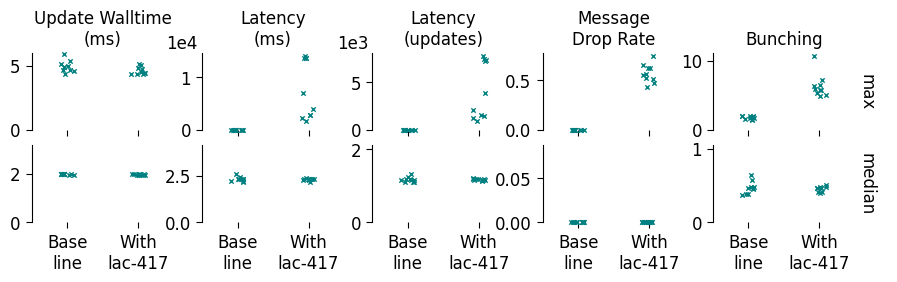

In [ ]:
with tp.teed(
    sns.catplot,
    data=pd.concat([data_max, data_median], ignore_index=True).replace(
        {
            allocation_idx_mapped_title: {
                0: "Base\nline",
                1: "With\nlac-417",
            },
            "Metric": {
                "Simstep Period Outlet (ms)": "Update Walltime\n(ms)",
                "Latency Simsteps Outlet": "Latency\n(updates)",
                "Latency Walltime Outlet (ms)": "Latency\n(ms)",
                "Delivery Clumpiness": "Bunching",
                "Delivery Failure Rate": "Message\nDrop Rate",
            },
        },
    ),
    col="Metric",
    col_order=[
        "Update Walltime\n(ms)",
        "Latency\n(ms)",
        "Latency\n(updates)",
        "Message\nDrop Rate",
        "Bunching",
    ],
    row="Kind",
    x=allocation_idx_mapped_title,
    order=["Base\nline", "With\nlac-417"],
    y="Value",
    clip_on=False,
    color="teal",
    kind="strip",
    linewidth=1,
    margin_titles=True,
    marker="x",
    edgecolor="teal",
    s=10,
    sharey=False,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.figure.set_size_inches(9, 2)
    _g.set_titles(col_template="{col_name}", row_template="{row_name}")
    _g.set(ylim=(0, None), xlabel="", ylabel="")
    plt.subplots_adjust(hspace=0.2, wspace=0.2)
    for _ax in _g.axes.flat:
        _ax.ticklabel_format(style="sci", axis="y", scilimits=(-4, 3))
        _ax.yaxis.get_offset_text().set_x(-0.25)
        _ax.yaxis.get_offset_text().set_y(0.5)
    for _ax in _g.axes[1, :].flat:
        _ax.set_ylim(1.6 * np.array(_ax.get_ylim()))
    sns.despine(fig=_g.figure, bottom=True)

teeplots/2026-05-16-lac-417/col=metric+hue=significance+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.pdf
teeplots/2026-05-16-lac-417/col=metric+hue=significance+kind=strip+marker=x+row=kind+viz=catplot+x=0-sans-lac-417-1-with-lac-417+y=value+ext=.png


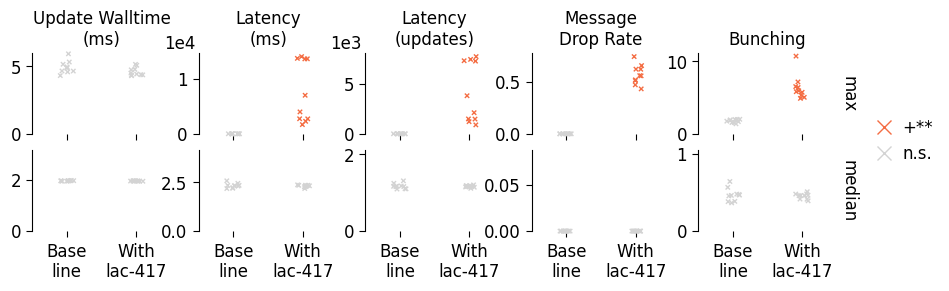

,Metric,Kind,Median Baseline,Median With lac-417,% Change,p-value,Significance
0,Bunching,max,1.790405,5.871893,227.964549,0.001953,+**
1,Bunching,median,0.464752,0.461561,-0.686611,0.769531,n.s.
2,Latency (ms),max,4.559967,5471.012397,119879.198582,0.001953,+**
3,Latency (ms),median,2.313937,2.312360,-0.068156,0.921875,n.s.
4,Latency (updates),max,2.336015,2958.708333,126556.214510,0.001953,+**
5,Latency (updates),median,1.165339,1.170401,0.434341,1.000000,n.s.
6,Message Drop Rate,max,0.000000,0.558917,NaN,0.001953,+**
7,Message Drop Rate,median,0.000000,0.000000,NaN,NaN,n.s.
8,Update Walltime (ms),max,4.891886,4.471100,-8.601708,0.105469,n.s.
9,Update Walltime (ms),median,1.968575,1.958975,-0.487645,0.064453,n.s.


In [ ]:
_data_combined = pd.concat(
    [data_max, data_median], ignore_index=True
).replace(
    {
        allocation_idx_mapped_title: {0: "Base\nline", 1: "With\nlac-417"},
        "Metric": {
            "Simstep Period Outlet (ms)": "Update Walltime\n(ms)",
            "Latency Simsteps Outlet": "Latency\n(updates)",
            "Latency Walltime Outlet (ms)": "Latency\n(ms)",
            "Delivery Clumpiness": "Bunching",
            "Delivery Failure Rate": "Message\nDrop Rate",
        },
    },
)

def _pvalue_to_sig(p, baseline, treatment):
    if p > 0.05:
        return "n.s."
    sign = "+" if np.median(treatment) >= np.median(baseline) else "−"
    if p < 0.001:
        return f"{sign}***"
    elif p < 0.01:
        return f"{sign}**"
    else:
        return f"{sign}*"

_data_combined["Significance"] = "n.s."
_stats_rows = []
for (_metric, _kind), _grp in _data_combined.groupby(["Metric", "Kind"]):
    _baseline = _grp.loc[
        _grp[allocation_idx_mapped_title] == "Base\nline", "Value"
    ].to_numpy()
    _treatment = _grp.loc[
        _grp[allocation_idx_mapped_title] == "With\nlac-417", "Value"
    ].to_numpy()
    _n = min(len(_baseline), len(_treatment))
    _p = np.nan
    try:
        _, _p = scipy_stats.wilcoxon(_baseline[:_n], _treatment[:_n])
        _sig = _pvalue_to_sig(_p, _baseline[:_n], _treatment[:_n])
    except ValueError:  # all zeros
        _sig = "n.s."

    _mask = (
        (_data_combined["Metric"] == _metric)
        & (_data_combined["Kind"] == _kind)
        & (_data_combined[allocation_idx_mapped_title] == "With\nlac-417")
    )
    _data_combined.loc[_mask, "Significance"] = _sig
    _med_b = np.median(_baseline) if len(_baseline) else np.nan
    _med_t = np.median(_treatment) if len(_treatment) else np.nan
    _pct = (
        (_med_t - _med_b) / _med_b * 100
        if _med_b not in (0, np.nan) and not np.isnan(_med_b)
        else np.nan
    )
    _stats_rows.append(
        {
            "Metric": _metric.replace("\n", " "),
            "Kind": _kind,
            "Median Baseline": _med_b,
            "Median With lac-417": _med_t,
            "% Change": _pct,
            "p-value": _p,
            "Significance": _sig,
        }
    )

_sig_palette = {
    "+***": "#d73027",
    "+**": "#f46d43",
    "+*": "#fdae61",
    "n.s.": "lightgray",
    "−*": "#c7eae5",
    "−**": "#5ab4ac",
    "−***": "#01665e",
}
_hue_order = [
    _s
    for _s in [
        "+***",
        "+**",
        "+*",
        "n.s.",
        "−*",
        "−**",
        "−***",
    ]
    if _s in _data_combined["Significance"].unique()
]

with tp.teed(
    sns.catplot,
    data=_data_combined,
    col="Metric",
    col_order=[
        "Update Walltime\n(ms)",
        "Latency\n(ms)",
        "Latency\n(updates)",
        "Message\nDrop Rate",
        "Bunching",
    ],
    row="Kind",
    x=allocation_idx_mapped_title,
    order=["Base\nline", "With\nlac-417"],
    y="Value",
    hue="Significance",
    hue_order=_hue_order,
    palette=_sig_palette,
    clip_on=False,
    kind="strip",
    linewidth=1,
    margin_titles=True,
    marker="x",
    s=10,
    sharey=False,
    dodge=False,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.figure.set_size_inches(9, 2)
    _g.set_titles(col_template="{col_name}", row_template="{row_name}")
    _g.set(ylim=(0, None), xlabel="", ylabel="")
    plt.subplots_adjust(hspace=0.2, wspace=0.2)
    for _ax in _g.axes.flat:
        _ax.ticklabel_format(style="sci", axis="y", scilimits=(-4, 3))
        _ax.yaxis.get_offset_text().set_x(-0.25)
        _ax.yaxis.get_offset_text().set_y(0.5)
    for _ax in _g.axes[1, :].flat:
        _ax.set_ylim(1.6 * np.array(_ax.get_ylim()))
    sns.despine(fig=_g.figure, bottom=True)
    sns.move_legend(
        _g,
        loc="center right",
        bbox_to_anchor=(1.04, 0.5),
        frameon=False,
        title=None,
        markerscale=3,
        handletextpad=0.1,
    )

stats_df = pd.DataFrame(_stats_rows)
stats_df